In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint

from plots import plot_harmonic_oscillator, plot_kepler

torch.manual_seed(42)

## План

**Физически информированные нейронные сети**
1. Гармонический осциллятор: PINN, learning $\omega$
2. Задача Кеплера: PINN: learning $e, a$

**Нейронные ОДУ**
1. Гармонический осциллятор: Neural ODE (single $x_0, y_0$), learning $d^2x/dt^2$


## PINN


Физическая информация хранится в наборе дифференциальных уравнений или других условий, накладываемых на параметры:
$$
F(x, y', y'', ... y^{(n)}) = 0,
$$
соответствующие потери можно выразить как 
$$
L_{\text{physics}} = MSE(F(x, y', y'', ... y^{(n)}), 0)
$$

Физически информированная нейронная сеть: такая, что 
$$
L(\vartheta) = L_{\text{reg}} + \lambda L_{\text{physics}}
$$
$\lambda$ вводится для балансировки вкладов. 




## Гармонический осциллятор: восстановление неизвестного параметра

$$
x''(t) + \omega^2 x(t) = 0
$$

Начальные условия: $x(0) = 1, \ x'(0) = 0$


In [3]:
def exact_solution(
        t: torch.Tensor | np.ndarray, 
        x0: float = 1., v0: float = 0., omega: float = 2.
    ) -> torch.Tensor | np.ndarray:
    """Solution for true dynamics
    d²x/dt² = -ω²x, with known x(0), x'(0)
    """
    x = x0 * np.cos(omega * t) + v0 / omega * np.sin(omega * t)
    return x

OMEGA = 2.
X0, V0 = 1., 0.

### Задание 1

1. Сгенерируйте $40$ зашумленных наблюдений вдоль траектории: $(t_{\text{obs}}, x_{\text{obs}}(t) + \varepsilon), t \in [0, 10]$, $\varepsilon\sim \mathcal{N}(0, 0.04)$

In [4]:
t_obs = 10 * torch.rand(40).view(-1,1)
x_obs = exact_solution(t=t_obs, omega=OMEGA, v0=V0, x0=X0) + 0.04 * torch.randn_like(t_obs)


2. Сгенерируйте набор отложенных данных. Например, 300 наблюдений вдоль траектории: $(t_{\text{test}}, x_{\text{test}})$, на которых будет проверяться модель

In [5]:
t_test = 10 * torch.linspace(0, 1, 300).view(-1,1)
x_test = exact_solution(t=t_test, omega=OMEGA, v0=V0, x0=X0)

Проверим, что получилось

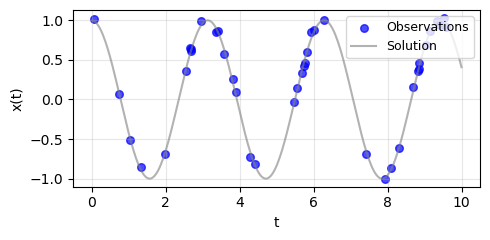

In [6]:
plot_harmonic_oscillator(
    t_obs=t_obs.flatten(), x_obs=x_obs.flatten(),
    t=t_test.flatten(), x=x_test.flatten()
    )

### Задание 2 


1. Реализуйте многослойный перцептрон для решения задачи регрессии $t \rightarrow x(t)$

2. Инициализируйте модель и оптимизатор

3. Задайте функцию потерь $L_{\text{physics}}$, которая отвечает за удовлетворение $x(t)$ уравнению осциллятора. Первые и вторые производные можно рассчитать с использованием `torch.autograd.grad`. [Ссылка на документацию](docs.pytorch.org/docs/stable/generated/torch.autograd.grad.html) 

4. Сделайте параметр $\omega$ оптимизируемым с использованием `torch.nn.Parameter`, включите его в функцию потерь



In [8]:
class PINN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16, output_dim=1): 
        super(PINN, self).__init__()
        # Input: [t]
        # Output: [u]
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2*hidden_dim),
            nn.Tanh(),
            nn.Linear(2*hidden_dim, output_dim)
        )
    
    def forward(self, t):
        return self.net(t)

In [9]:
model_oscillator = PINN(hidden_dim=32)

omega = torch.nn.Parameter(torch.ones(1, requires_grad=True))
omegas = [] # to track omega

optimizer = torch.optim.Adam(list(model_oscillator.parameters())+[omega], lr=1e-3)

In [10]:
t_physics =  torch.linspace(0, 10., 50).view(-1,1).requires_grad_(True)

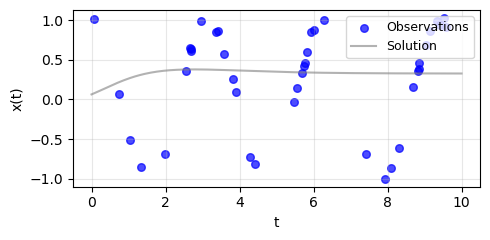

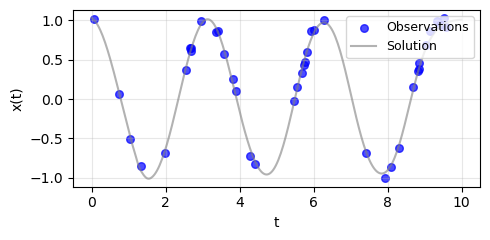

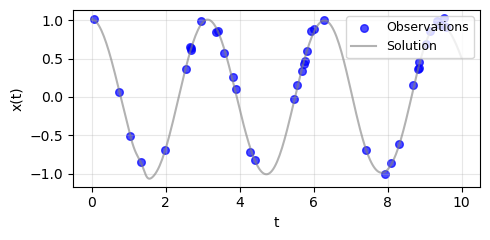

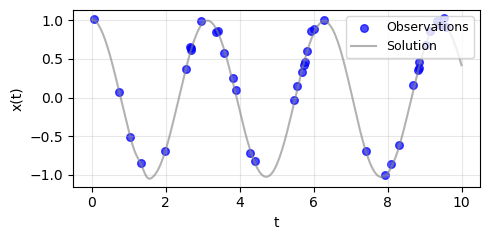

In [11]:
lambda1 = 1e2

for epoch in range(0, 15_001):
    optimizer.zero_grad()
    
    x = model_oscillator(t_physics)

    dxdt = torch.autograd.grad(x, t_physics, torch.ones_like(x), create_graph=True)[0]
    d2xdt2 = torch.autograd.grad(dxdt, t_physics, torch.ones_like(dxdt), create_graph=True)[0]
    
    loss_physics = torch.mean((d2xdt2 + omega**2*x)**2)
   
    x = model_oscillator(t_obs)
    loss_reg = torch.mean((x - x_obs)**2)
        
    loss = loss_physics + lambda1*loss_reg
    loss.backward()
    optimizer.step()

    omegas.append(omega.item())

    if epoch % 5_000 == 0:
        with torch.no_grad():
            x = model_oscillator(t_test)

        plot_harmonic_oscillator(
            t_obs.flatten(), x_obs.flatten(),
            t_test.flatten(),  x.flatten()
        )



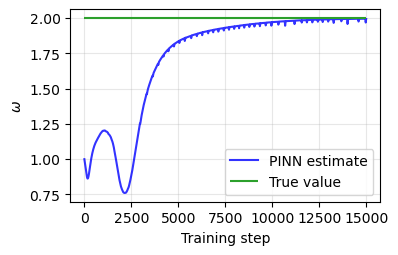

In [12]:
plt.figure(figsize=(4, 2.5))
plt.plot(omegas, color='b', alpha=0.8, label="PINN estimate")
plt.hlines(OMEGA, 0, len(omegas), label="True value", color="tab:green")
plt.grid(True, alpha=0.3)
plt.xlabel("Training step")
plt.ylabel('$\omega$')
plt.legend()

plt.show()

## Задача Кеплера

В полярной системе координат траектория задается 
$$
\rho = \frac{a(1-e^2)}{1+e\cos{(\varphi)}}
$$
- $\rho$ — расстояние от тела до гравитирующего центра, 
- $ \varphi $ — истинная аномалия или угол между направлениями на перицентр орбиты и на тело, 
- $e$ — эксцентриситет,
- $a$ — большая полуось орбиты.

При замене $u = 1/\rho$ уравнение движения может быть записано как (формула Бине)
$$
\frac{d^2u}{d\varphi^2} + u = \frac{1}{a(1-e^2)}
$$
При этом
$$
\rho= \frac{1}{u} = \frac{a(1-e^2)}{1+e\cos{(\varphi)}}
$$


In [13]:
a, e = 1.5, 0.7
P = a * (1 - e**2)

def exact_solution_kepler(phi, a=1.5, e=0.7):
    """
    Solution for true kepler dynamics
    """
    return  a * (1 - e**2)/(1+e*np.cos(phi))


### Задание 1

1. Сгенерируйте 40 зашумленных наблюдений вдоль траектории $(\varphi_{\text{obs}}, \rho_{\text{obs}} + \varepsilon)$ на двух периодах вращения $\varphi \in [0, 4\pi]$. $\varepsilon \sim \mathcal{N}(0, 0.04)$. Для обучения модели будет использоваться  
$$
D = \{\varphi_{\text{obs}}, u_{\text{obs}}\}, \ \ u_{\text{obs}}=1/\rho_{\text{obs}}
$$ 

2.  Сгенерируйте ~300 примеров точной зависимости $(\varphi_{\text{test}}, u_{\text{test}})$. 



In [14]:
scale = 4 * np.pi 
phi_obs = scale * torch.rand(40).view(-1,1)
r_obs = exact_solution_kepler(phi_obs) + 0.04*torch.randn_like(phi_obs)
u_obs = 1/r_obs.view(-1,1)

phi_exact = scale * torch.linspace(0, 1, 300).view(-1,1)
r_exact = exact_solution_kepler(phi_exact)
u_exact = 1/r_exact.view(-1,1)


Проверим, что получилось

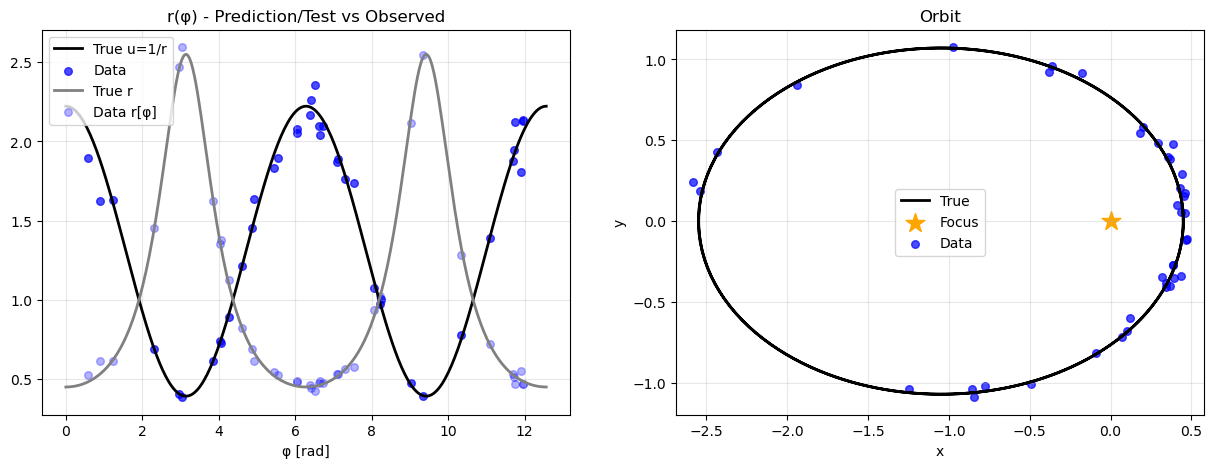

In [15]:
plot_kepler(phi_exact, r_exact, phi_obs, r_obs)

### Задание 2

1. Дополните процедуру обучения: реализуйте регрессионные и физические потери с учетом уравнения движения. 

In [16]:
def train_pinn_kepler(
        model: nn.Module, 
        phi_obs: torch.Tensor, u_obs: torch.Tensor, 
        n_epochs: int = 5000
        ) -> tuple[nn.Module, dict]:
    """
    Balanced training that respects both data and physics
    """
    global scale, P

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    phi_physics = torch.linspace(0, scale, 500).view(-1,1).requires_grad_(True)
    u_std = u_obs.std().item() # to balance losses

    print("Training PINN")

    for epoch in range(n_epochs):

        # Regression loss
        u_pred_obs = model(phi_obs)
        loss_reg = torch.mean((u_pred_obs - u_obs)**2) / u_std**2

        # Physics loss
        u = model(phi_physics)

        du_dphi = torch.autograd.grad(u, phi_physics, 
                                    grad_outputs=torch.ones_like(u),
                                    create_graph=True,
                                    retain_graph=True)[0]
        
        d2u_dphi2 = torch.autograd.grad(du_dphi, phi_physics,
                                        grad_outputs=torch.ones_like(du_dphi),
                                        create_graph=True,
                                        retain_graph=True)[0]
        
        loss_phys = torch.mean((d2u_dphi2 + u - 1/P)**2) 
        
        loss =  loss_reg + loss_phys
        
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        if (epoch + 1) % 3000 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}")
            print(f"  Loss: Total={loss.item():.6f}, Reg={loss_reg.item():.6f}, Phys={loss_phys.item():.6f}")
            print()
    
    return model


In [17]:
model_kepler = PINN(hidden_dim=32)

In [18]:
model_kepler = train_pinn_kepler(model_kepler, phi_obs, u_obs, n_epochs=15000)

Training PINN
Epoch 3000/15000
  Loss: Total=0.142950, Reg=0.064678, Phys=0.078272

Epoch 6000/15000
  Loss: Total=0.137609, Reg=0.046355, Phys=0.091254

Epoch 9000/15000
  Loss: Total=0.110253, Reg=0.043853, Phys=0.066401

Epoch 12000/15000
  Loss: Total=0.100565, Reg=0.051566, Phys=0.048999

Epoch 15000/15000
  Loss: Total=0.111158, Reg=0.046028, Phys=0.065130



2. На тестовых данных 2.5 периодов проверьте сходимость модели

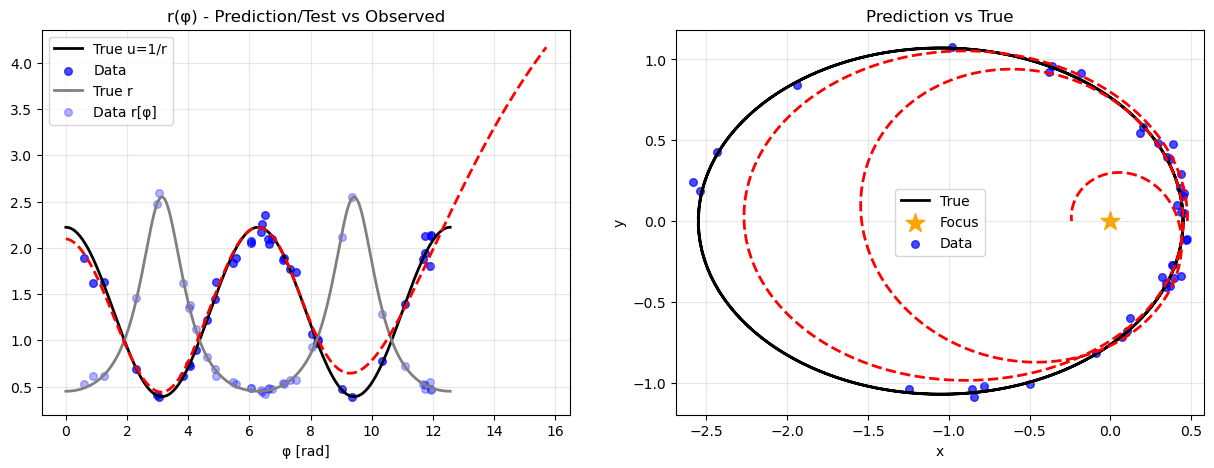

In [19]:
phi_test = torch.linspace(0, 5*np.pi, 1000).view(-1,1)

with torch.no_grad():
    u_pred = model_kepler(phi_test)
  
plot_kepler(phi_exact, r_exact, phi_obs, r_obs, phi_test, 1/u_pred)

## Гармонический осциллятор: NeuralODE, restore true dynamics

$$
x''(t) + \omega^2 x(t) = 0
$$

Начальные условия: $x(0) = 1, \ x'(0) = 0$

**Цель:** восстановить настоящую динамику, т.е. $x''(t) = - \omega^2 x(t)$


## Задание 1

1. Задайте истинную динамику системы, которая по входному состоянию $(x, dx/dt)$ рассчитывает $dx/dt, d^2x/dt^2$.

2. Задайте начальное состояние системы $(x_0, v_0)$. С помощью `torchdiffeq.odeint` получите несколько (~30) наблюдений вдоль траектории $\{x_{\text{obs}}(t), v_{\text{obs}}(t)\}$. Добавьте шум к измерениям $x, v$


In [20]:
def true_dynamics(t, state):
    global OMEGA
    x, v = state
    return torch.stack([v, -OMEGA**2 * x]) # dx/dt, d2x/dt2

In [21]:
t_span = torch.linspace(0, 10., 30)
initial_state = torch.tensor([X0, V0])

true_traj = odeint(true_dynamics, initial_state, t_span)
obs_traj = true_traj + 0.04 * torch.randn_like(true_traj) # noise

t_test = torch.linspace(0, 10., 200)
traj_test = odeint(true_dynamics, initial_state, t_test)

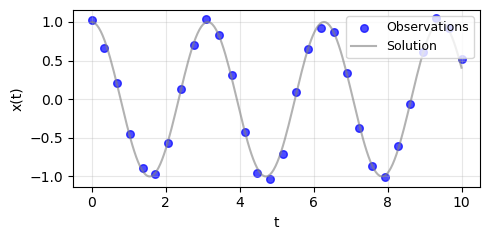

In [22]:
plot_harmonic_oscillator(
    t_span, obs_traj[:, 0], t_test, traj_test[:, 0]
)

### Задание 2

1. Реализуйте многослойный перцептрон, представляющий ОДУ $f()$: 
$$
(x(t_i), v(t_i)) \overset{f()}{\rightarrow} ((dx/dt)(t_i), (d^2x/dt^2)(t_i))
$$

In [23]:
class NeuralODE(nn.Module):
    def __init__(self, input_dim=2, output_dim=2, hidden_dim=16): 
        super(NeuralODE, self).__init__()
        # Input: [x, x']
        # Output: [x', x'']
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2*hidden_dim),
            nn.Tanh(),
            nn.Linear(2*hidden_dim, output_dim)
        )
    
    def forward(self, t, state): # t parameter is only for odeint
        return self.net(state)

2. Реализуйте процедуру обучения модели. Потери задаются таким образом, чтобы интегрированные траектории совпадали. Траектории можно интегрировать с использованием `odeint(f, initial_condition, t)`

Training Neural ODE
Epoch 0, Loss: 1.471682
--- x(t) ---


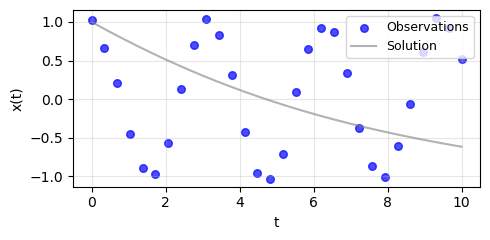

--- dx/dt ---


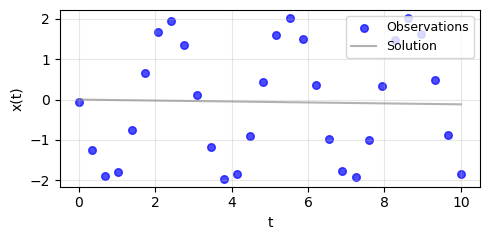

Epoch 300, Loss: 0.133920
--- x(t) ---


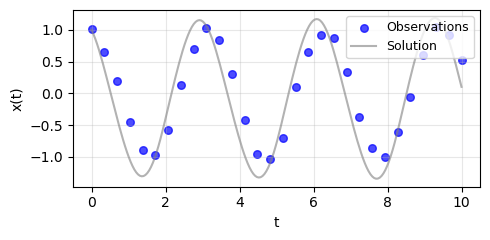

--- dx/dt ---


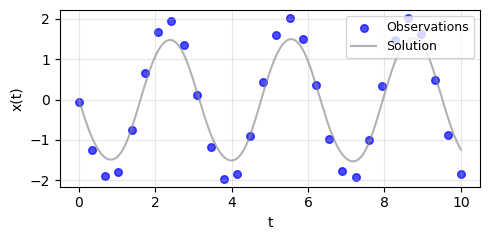

Epoch 600, Loss: 0.017432
--- x(t) ---


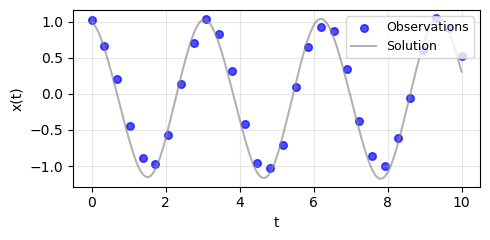

--- dx/dt ---


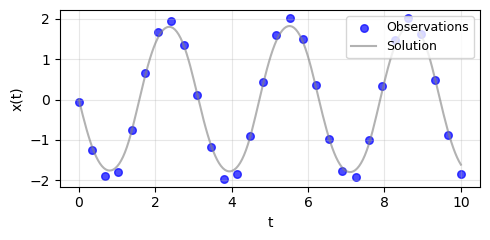

Epoch 900, Loss: 0.003607
--- x(t) ---


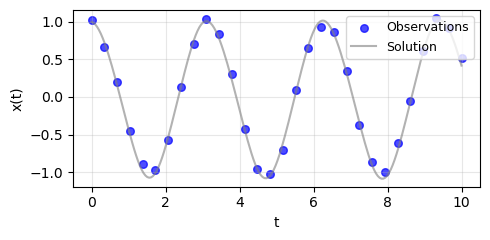

--- dx/dt ---


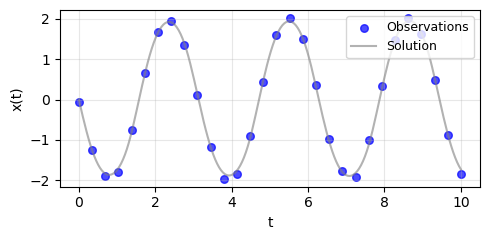

In [24]:
model_node = NeuralODE(hidden_dim=32)
optimizer = torch.optim.Adam(model_node.parameters(), lr=1e-3)

print("Training Neural ODE")
for epoch in range(1000):
    pred_traj = odeint(model_node, initial_state, t_span)
    loss = torch.mean((pred_traj - obs_traj)**2)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 300 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")
    
        with torch.no_grad():
            u = odeint(model_node, initial_state, t_test)

        print('--- x(t) ---')
        plot_harmonic_oscillator(
            t_span.flatten(), obs_traj[:, 0].flatten(),
            t_test.flatten(),  u[:, 0].flatten()
        )
        print('--- dx/dt ---')
        plot_harmonic_oscillator(
            t_span.flatten(), obs_traj[:, 1].flatten(),
            t_test.flatten(),  u[:, 1].flatten()
        )



3. Для проверки постройте траектории с другими НУ.

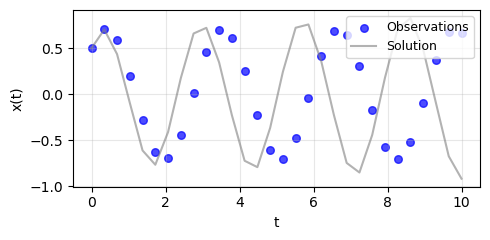

In [25]:
new_x0, new_v0 = 0.5, 1.0
new_initial = torch.tensor([new_x0, new_v0])

new_true = odeint(true_dynamics, new_initial, t_span)
new_pred = odeint(model_node, new_initial, t_span).detach()

plot_harmonic_oscillator(
    t_span, new_true[:, 0], t_span, new_pred[:, 0]
)

4. Сравните динамику, выученную нейронной сетью, с реальной динамикой для задачи гармонического осциллятора $d^2x/dt^2 = -\omega^2 x$. Для этого нужно учесть, что нас интересует динамика вдоль траектории с заданным ранее НУ. 

    - сгенерируйте наблюдаемую траекторию  $(x(t), v(t))$
    - в каждой точке вдоль траектории получите $d^2x/dt^2 (t)$
    - сравните с теоретическим $d^2x/dt^2 (t)$


In [26]:
def exact_solution_xv(
        t: torch.Tensor | np.ndarray, 
        x0: float = 1., v0: float = 1, omega: float = 2.
    ) -> torch.Tensor | np.ndarray:
    """Solution for true dynamics
    d²x/dt² = -ω²x, with known x(0), x'(0)
    """
    x = x0 * torch.cos(omega * t) + v0 / omega * torch.sin(omega * t)
    v = x0 * torch.sin(omega * t) - v0 * torch.cos(omega * t)
    return torch.stack([x, v]).T

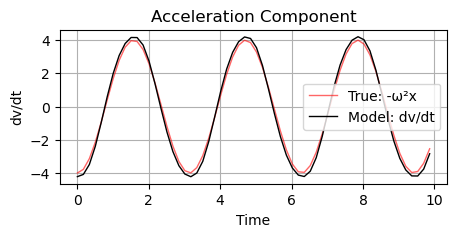

In [27]:
t = torch.linspace(0, 10., 300)

with torch.no_grad():
    given_trajectory = exact_solution_xv(t, X0, V0, OMEGA) 
    x_true = given_trajectory[:, 0]
    dvdt_pred = model_node(0, given_trajectory)[:, 1]
    

t_sample = t[::5]
dvdt_true = -OMEGA**2 *x_true[::5]
dvdt_pred = dvdt_pred[::5]

fig, ax = plt.subplots(1, 1, figsize=(5, 2))

ax.plot(t_sample.numpy(), dvdt_true.numpy(), 'r-',  linewidth=1, alpha=0.6, label='True: -ω²x')
ax.plot(t_sample.numpy(), dvdt_pred.numpy(), 'k-', linewidth=1, label='Model: dv/dt')
ax.set_xlabel('Time')
ax.set_ylabel('dv/dt')
ax.set_title('Acceleration Component')
ax.legend()
ax.grid(True)